# Regression Metrics

1. MAE 

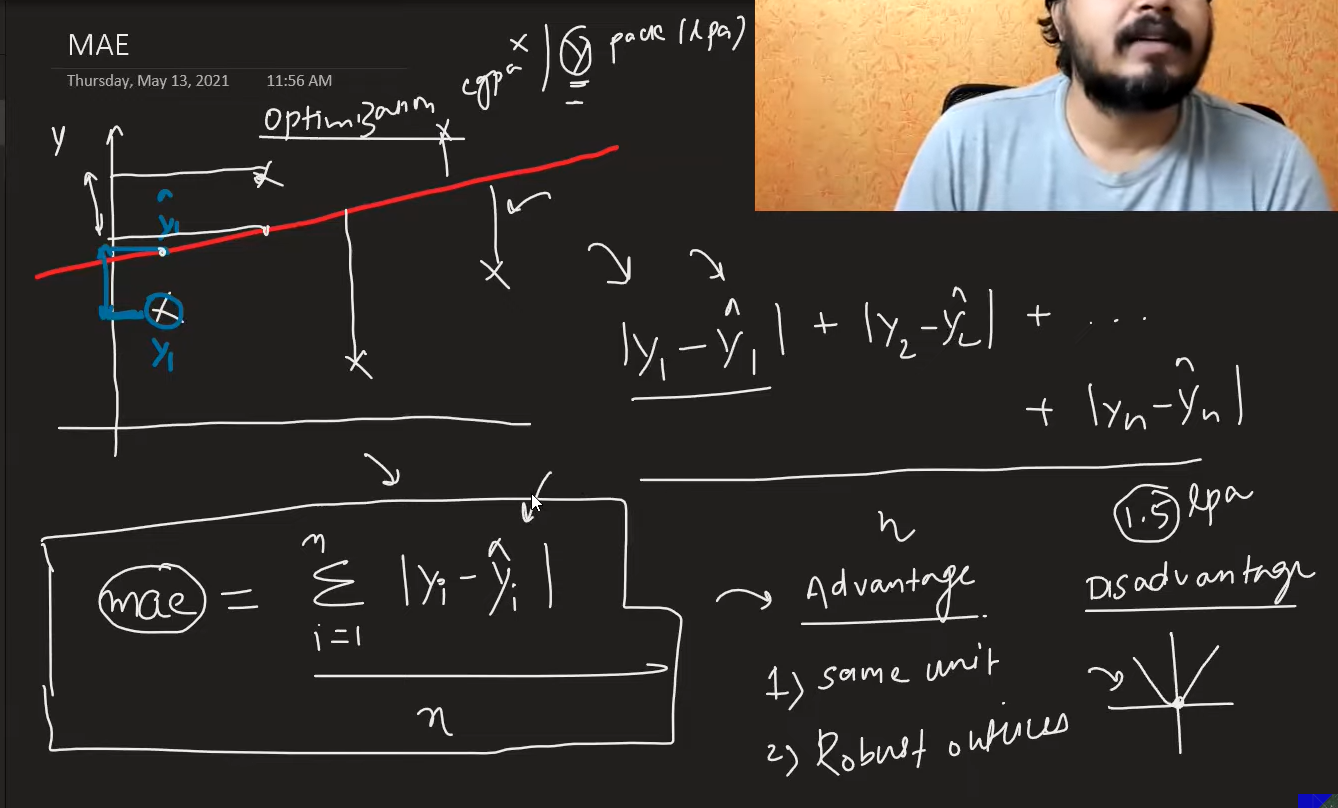

2. MSE

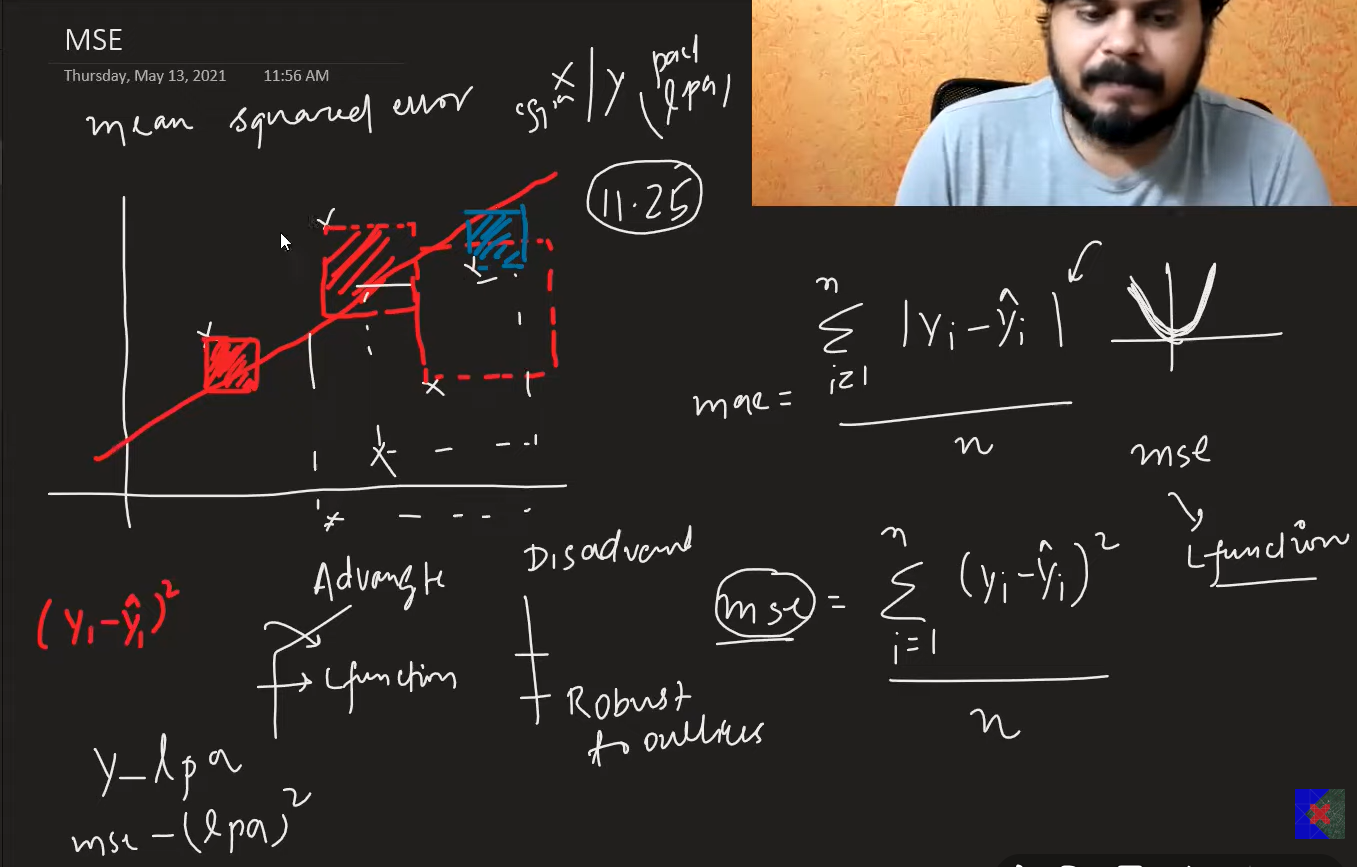

3. RMSE

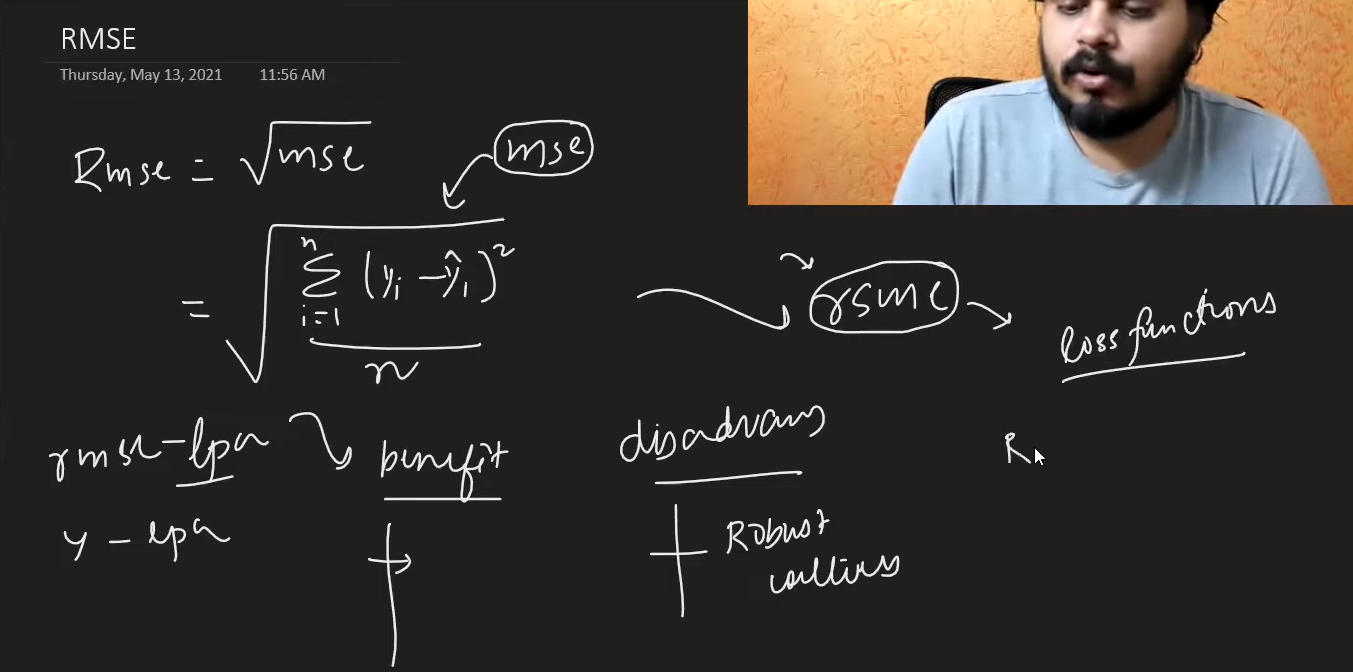

4. R2 SCORE (shows how goos we are performing ) 

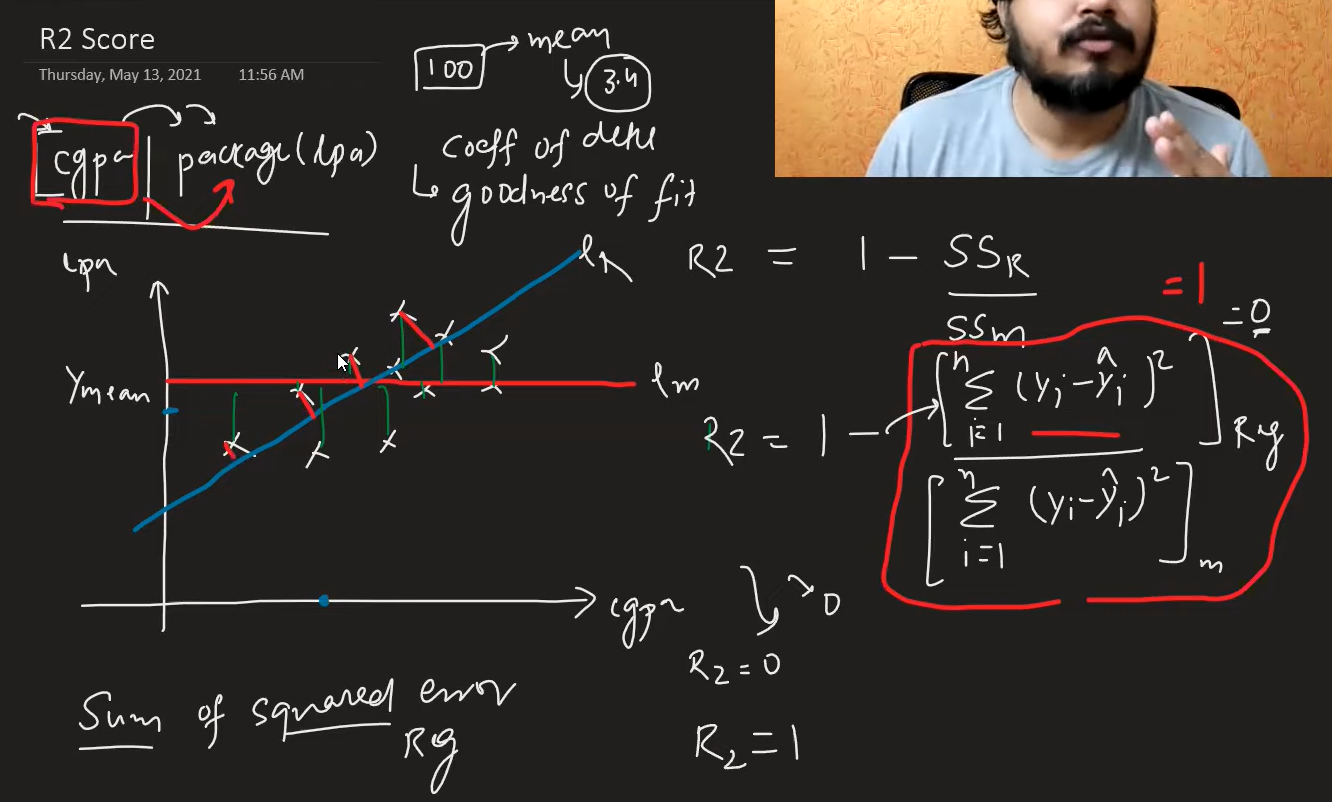


problem when more input more r2 score whicj is not always true 
like cg salary originally when more input added tempreature relevant still r2 score more 
to tackle this we have adjusted r2 score

5 Adjusted R2 Score 

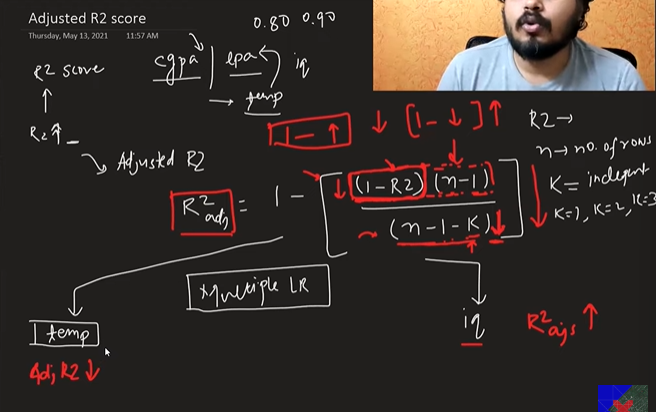

### Demo Code

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [61]:
df=pd.read_csv('placements.csv')

In [62]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


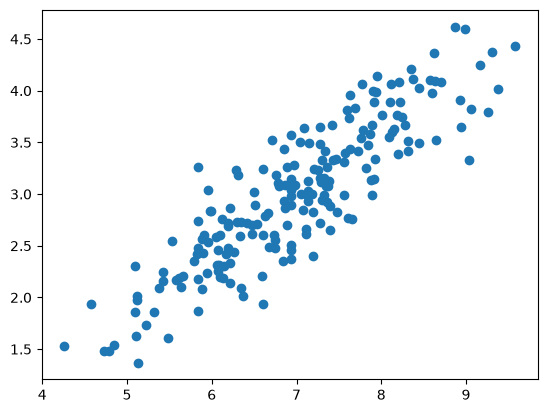

In [63]:
plt.scatter(x=df['cgpa'],y=df['package'])

In [64]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [65]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [66]:
from sklearn.linear_model import LinearRegression

In [67]:
lr = LinearRegression()

In [68]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.56]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.8961
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


Text(0, 0.5, 'Package(in lpa)')

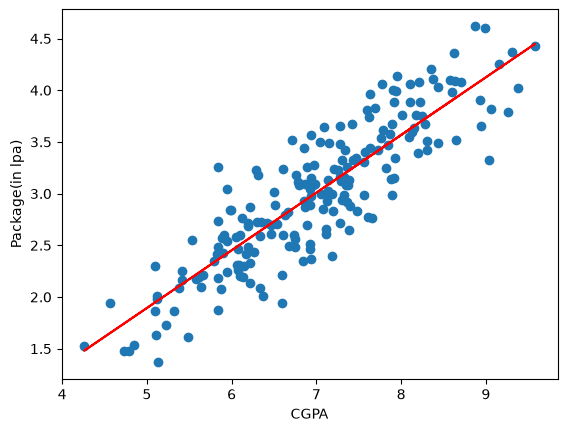

In [69]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [70]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [71]:
y_pred=lr.predict(X_test)

In [72]:
print ("MAE :",mean_absolute_error(y_test,y_pred))

MAE : 0.2884710931878175


In [73]:
print ("MSE :",mean_squared_error(y_test,y_pred))

MSE : 0.12129235313495527


In [74]:
print ("RMSE :",np.sqrt(mean_squared_error(y_test,y_pred)))  # this 0.3 is lpa

RMSE : 0.34827051717731616


In [75]:
print ("R2 SCORE:",r2_score(y_test,y_pred))

R2 SCORE: 0.780730147510384


In [76]:
r2=r2_score(y_test,y_pred)

In [77]:
# Adjusted R2 Score 
X_test.shape

(40, 1)

In [78]:
1-((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

#### Now lets just add a random feature and lets see the how r2 score reacts to it

In [79]:
new_df1=df.copy()
new_df1['random_feature']=np.random.random(200)

new_df1=new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.245895,3.26
1,5.12,0.291704,1.98
2,7.82,0.590484,3.25
3,7.42,0.896878,3.67
4,6.94,0.643793,3.57


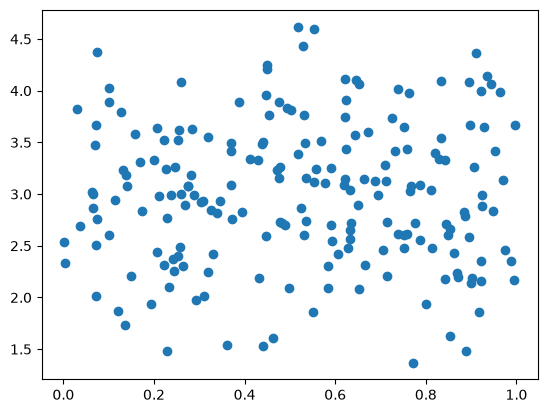

In [80]:
plt.scatter(x=new_df1['random_feature'],y=new_df1['package'])

In [81]:
X1=new_df1.iloc[:,0:2]
y1=new_df1.iloc[:,-1]

In [82]:
X1_train,X1_test,y1_train,y1_test = train_test_split(X1,y1,test_size=0.2,random_state=2)

In [83]:
lr1=LinearRegression()

In [84]:
lr1.fit(X1_train,y1_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.56,0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','random_feature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.9299
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [85]:
y1_pred=lr1.predict(X1_test)

In [86]:
print ("R2 SCORE:",r2_score(y1_test,y1_pred))

R2 SCORE: 0.7817065443888889


In [87]:
r2_new=r2_score(y1_test,y1_pred)

In [88]:
1-((1-r2_new)*(40-1)/(40-1-1))

0.7759619797675439

### Now lets add new col which is releveant and see how r2 behaves

In [89]:
new_df2=df.copy()
new_df2['iq']=new_df2['package']+ (np.random.randint(-12,12,200)/10)

new_df2=new_df2[['cgpa','iq','package']]
new_df2.head()

,cgpa,iq,package
0,6.89,4.26,3.26
1,5.12,2.28,1.98
2,7.82,2.95,3.25
3,7.42,4.77,3.67
4,6.94,3.67,3.57


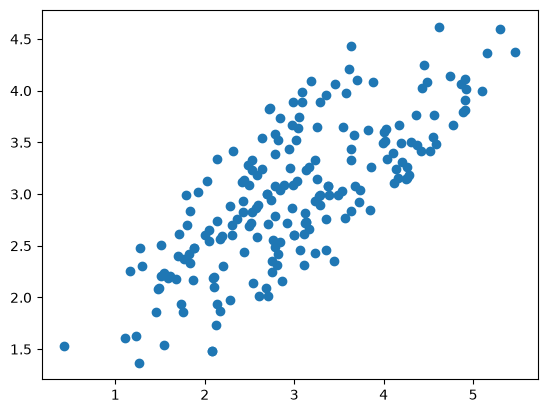

In [91]:
plt.scatter(x=new_df2['iq'],y=new_df1['package'])

In [92]:
np.random.randint(-100,100)

-48

In [93]:
X2=new_df2.iloc[:,0:2]
y2=new_df2.iloc[:,-1]

In [94]:
X2_train,X2_test,y2_train,y2_test = train_test_split(X2,y2,test_size=0.2,random_state=2)

In [95]:
lr2=LinearRegression()
lr2.fit(X2_train,y2_train)
y2_pred=lr2.predict(X2_test)

In [100]:
print ("R2 SCORE:",r2_score(y2_test,y2_pred))
r2_new1=r2_score(y2_test,y2_pred)

R2 SCORE: 0.8366649803424993


In [101]:
1-((1-r2_new1)*(40-1)/(40-1-1))

0.8323666903515123